# Annotation and Neighborhood enrichment analysis for the ROIs
In this html I am showing the annotation and Niche annoattions for the ROIs identified by Erica.

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time
import sys
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import seaborn as sns
import math
import os
import re

The ROIs that I am showing are:

In [2]:
path = "/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/"

all_files = os.listdir(path)
pattern = re.compile(r'(.+)_sigma_binary_res')

# Extract matching sample names
sample_names = []
for file in all_files:
    match = pattern.match(file)
    if match:
        sample_names.append(match.group(1)) 

In [4]:
#create def to create a new table:
all_sample_merged_table= []
for sample_name in sample_names:
    annota_table = pd.read_table(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/cell_annotation.txt')
    raw_table = pd.read_csv(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/raw_metadata.csv')
    #print(annota_table['cell_id'].isin(raw_table['Object Id']).all())
    merged_table = pd.merge(
        raw_table,
        annota_table,
        left_on='Object Id',
        right_on='cell_id',
        how='inner'
    )
    merged_table['sample_region']=sample_name
    all_sample_merged_table.append(merged_table)

all_sample_merged_table = pd.concat(all_sample_merged_table, axis=0).reset_index(drop=True)

In [5]:
all_sample_merged_table.loc[all_sample_merged_table['sample_region'] == 'NEST1-06_tumor_inner', 'sample_region'] = 'NEST1-06_tumor_bed'

In [6]:
all_zscore_table= []
for sample_name in sample_names:
    norm_data = pd.read_csv(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/z_score_normalization.csv')
    norm_data['sample_region']=sample_name
    all_zscore_table.append(norm_data)

all_zscore_table = pd.concat(all_zscore_table, axis=0).reset_index(drop=True)

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


In [7]:
all_zscore_table.loc[all_zscore_table['sample_region'] == 'NEST1-06_tumor_inner', 'sample_region'] = 'NEST1-06_tumor_bed'

In [8]:
all_sample_merged_table2 = all_sample_merged_table

In [9]:
normalized_df = all_sample_merged_table2.merge(all_zscore_table, on=['cell_id', 'sample_region'], how='left')


In [10]:
normalized_df.to_csv('all_merge_normalize_data.csv', index=False) 

In [11]:
normalized_df.shape

(1842939, 44)

In [12]:
# rename the cell type as they wnated. based on the markers used to annotate them.
probes_list =pd.read_csv("/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/probes_cell_type_table.csv",header=0)

In [13]:
probes_list

,celll_type,new_cell_type_name
0,B_cell,B_cell
1,T_cell,CD3E_CD4_CD8 (Tcell)
2,NK,NK
3,Epithelial,Epithelial
4,Lymphatic_endothelium,Lymphatic_endothelium
5,Endothelial,Endothelial
6,Macrophages,Macrophages
7,Plasma,Plasma
8,Smooth_muscle,Smooth_muscle
9,Stromal,Stromal


In [14]:
normalized_df = pd.merge(normalized_df, probes_list, on="celll_type")


In [15]:
# Dot plot z-score instensities of the probes based on the cell types for each sample

## Numbers and proportions of cell types in each ROI
Based on the stringent annotation system these are the raw numbers and proportions of cell types in each ROI.

### Raw numbers

In [16]:
all_sample_merged_table = pd.merge(all_sample_merged_table, probes_list, on="celll_type")

In [17]:
all_sample_merged_table.loc[all_sample_merged_table['sample_region'] == 'NEST1-04_tumor', 'sample_region'] = 'NEST1-04_tumor_inner'


In [ ]:
all_sample_merged_table['sample_region'].value_counts()

In [19]:
#they have decided to combine cell types.
all_sample_merged_table["combined_names"]=all_sample_merged_table["new_cell_type_name"]
all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'CD4', 'combined_names'] = 'CD4_T_cell'
all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'CD3E_CD4 (CD4_Tcell)', 'combined_names'] = 'CD4_T_cell'
all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'CD4_LAG3_Tcell', 'combined_names'] = 'CD4_T_cell'



all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'CD8', 'combined_names'] = 'CD8_T_cell'
all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'CD3E_CD8 (CD8_Tcell)', 'combined_names'] = 'CD8_T_cell'
all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'CD8_LAG3_Tcell', 'combined_names'] = 'CD8_T_cell'



all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'CD3E_CD4_CD8 (Tcell)', 'combined_names'] = 'T_cell'
all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'LAG3_Tcell', 'combined_names'] = 'T_cell'



all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'FOXP3', 'combined_names'] = 'T_reg'
all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'CD3E_FOXP3 (T_regs)', 'combined_names'] = 'T_reg'



all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'CD3E_CD8_FOXP3 (CD8_Tregs)', 'combined_names'] = 'CD8_Treg'

all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'CD3E_CD4_FOXP3 (CD4_Tregs)', 'combined_names'] = 'CD4_Treg'

all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'Macrophages', 'combined_names'] = 'M1_Macrophages'
all_sample_merged_table.loc[all_sample_merged_table['new_cell_type_name'] == 'Th2_Macrophage', 'combined_names'] = 'M2_Macrophages'





In [ ]:
pd.crosstab(all_sample_merged_table['sample_region'], all_sample_merged_table['combined_names'])


In [21]:
celltype_counts = pd.crosstab(all_sample_merged_table['sample_region'], all_sample_merged_table['combined_names'])
celltype_counts.columns

Index(['B_cell', 'CD4_T_cell', 'CD4_Treg', 'CD8_T_cell', 'CD8_Treg',
       'Endothelial', 'Epithelial', 'Lymphatic_endothelium', 'M1_Macrophages',
       'M2_Macrophages', 'NK', 'Plasma', 'Smooth_muscle', 'Stromal', 'T_cell',
       'T_reg', 'Unknown'],
      dtype='object', name='combined_names')

### Total immune counts

In [22]:
keep_immuns = ['B_cell', 'CD4_T_cell', 'CD4_Treg', 'CD8_T_cell', 'CD8_Treg', 'M1_Macrophages',
       'M2_Macrophages', 'NK', 'Plasma', 'T_cell','T_reg']
print(f' The cell types I am keeping for number of immune cells are: {keep_immuns}')

 The cell types I am keeping for number of immune cells are: ['B_cell', 'CD4_T_cell', 'CD4_Treg', 'CD8_T_cell', 'CD8_Treg', 'M1_Macrophages', 'M2_Macrophages', 'NK', 'Plasma', 'T_cell', 'T_reg']


In [ ]:
sub_immune_celltype_counts = celltype_counts.loc[:, celltype_counts.columns.isin(keep_immuns)]
sub_immune_celltype_counts.sum(axis=1)

### Proportions

In [ ]:
pd.crosstab(all_sample_merged_table['sample_region'], all_sample_merged_table['combined_names'], normalize='index')


In [25]:
#all_sample_merged_table["combined_names"].value_counts()

### Barplot of the proportions

In [26]:
desired_order = ['NEST2-06_tumor_bed',
 'NEST1-05_tumor_bed',
 'NEST1-06_tumor_bed',
 'NEST1-11_tumor_bed',
 'NEST1-01_tumor_bed',
 'NEST2-01_tumor_bed',
 'NEST2-03_tumor_bed',
 'NEST1-08_tumor_inner',
 'NEST2-04_tumor_inner',
 'NEST2-10_tumor_inner',
 'NEST1-04_tumor_inner',
 'NEST1-04_tumor',
 'NEST2-08a_tumor',
 'NEST2-06_tumor',
 'NEST1-05_tumor',
 'NEST2-04_tumor',
 'NEST1-11_tumor']

In [27]:
celltype_colors = {
    "NK": "#1f77b4",
    "CD8_T_cell": "#2ca02c",
    "Endothelial": "#d62728",
    "Unknown": "#843c39",
    "B_cell": "#8c564b",
    "T_reg": "#e377c2",
    "Lymphatic_endothelium": "#7f7f7f",
    "Smooth_muscle": "#aec7e8",
    "CD8_Treg": "#ffbb78",
    "CD4_T_cell": "#98df8a",
    "M1_Macrophages": "#c5b0d5",
    "T_cell": "#c49c94",
    "Epithelial": "#f7b6d2",
    "CD4_Treg": "#393b79",
    "Stromal": "#637939",
    "M2_Macrophages": "#ff9896",
    "Plasma": "#9467bd"
}

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df= pd.crosstab(all_sample_merged_table['sample_region'], all_sample_merged_table['combined_names'], normalize='index')
df = df.loc[[s for s in desired_order if s in df.index]]
colors = [celltype_colors[ct] for ct in df.columns]

# Get unique cell types
cell_types = df.columns
n_types = len(cell_types)

# Mix two palettes
#palette1 = sns.color_palette("Set3", 12)    # Soft pastel colors
#palette2 = sns.color_palette("Paired", 12)  # Vibrant paired colors

# Combine them
#mixed_palette = palette1 + palette2         # Total = 24 colors

# Use only as many as needed
#final_palette = mixed_palette[:n_types]

# Plot with the mixed palette
ax = df.plot(kind='bar',
             stacked=True,
             figsize=(12, 6),
             color=colors)

# Format
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cell Type")
ax.grid(False)
plt.title('Percentage of Cell Types')
plt.xlabel('Sample Name')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()


In [29]:
#remove unknow to find clusters?
clean_all_sample_merged_table = all_sample_merged_table[all_sample_merged_table['combined_names']!='Unknown']

### Proportions after removing the "Unknown" cells.

In [ ]:
df= pd.crosstab(clean_all_sample_merged_table['sample_region'], clean_all_sample_merged_table['combined_names'], normalize='index')
df = df.loc[[s for s in desired_order if s in df.index]]

# Get unique cell types
cell_types = df.columns
n_types = len(cell_types)

# Mix two palettes
palette1 = sns.color_palette("Set3", 12)    # Soft pastel colors
palette2 = sns.color_palette("Paired", 12)  # Vibrant paired colors

# Combine them
mixed_palette = palette1 + palette2         # Total = 24 colors

# Use only as many as needed
final_palette = mixed_palette[:n_types]

# Plot with the mixed palette
ax = df.plot(kind='bar',
             stacked=True,
             figsize=(12, 6),
             color=colors)

# Format
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cell Type")
ax.grid(False)
plt.title('Percentage of Cell Types')
plt.xlabel('Sample Name')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()

### Image of the ROIs based on all the annotations with "Unknown" removed

In [ ]:
from matplotlib.lines import Line2D

cell_types = sorted(clean_all_sample_merged_table['combined_names'].dropna().unique())
n_types = len(cell_types)

# Create mixed color palette
#palette1 = sns.color_palette("Set3", 12)
#palette2 = sns.color_palette("Paired", 12)
#final_palette = (palette1 + palette2)[:n_types]
#color_map = dict(zip(cell_types, final_palette))

# 2. Plot setup
samples = clean_all_sample_merged_table['sample_region'].unique()
n_cols = 3
n_rows = math.ceil(len(samples) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
axes = axes.flatten()

# 3. Loop through samples
for i, sample in enumerate(samples):
    ax = axes[i]
    subset = clean_all_sample_merged_table[clean_all_sample_merged_table['sample_region'] == sample]

    if subset.empty:
        ax.set_visible(False)
        continue

    # Map colors to cell types
    colors = subset['combined_names'].map(celltype_colors)

    ax.scatter(
        subset['xmean'],
        subset['ymean'],
        c=colors,
        s=2
    )
    ax.set_title(f"{sample}", fontsize=10)
    ax.axis('off')

# 4. Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# 5. Add shared legend (once, outside the grid)
handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=celltype_colors[ct], markersize=5)
    for ct in cell_types
]
fig.legend(
    handles, cell_types, title="Cell Type",
    loc='upper right', fontsize=16, title_fontsize=16
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for legend
plt.show()


### Distribution of each cell type across the ROIs

In [ ]:
color_map = dict(zip(df.columns, final_palette))

for sample in clean_all_sample_merged_table['sample_region'].unique():
    sample_data = clean_all_sample_merged_table[clean_all_sample_merged_table['sample_region'] == sample]
    cell_types = sample_data['combined_names'].unique()

    n_cols = 3
    n_rows = math.ceil(len(cell_types) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    for i, cell_type in enumerate(cell_types):
        ax = axes[i]
        subset = sample_data[sample_data['combined_names'] == cell_type]
        color = celltype_colors.get(cell_type, 'gray')  # fallback color if missing
        sns.scatterplot(data=subset, x='xmean', y='ymean', s=10, ax=ax, color=color)
        ax.set_title(cell_type)
        ax.set_aspect('equal')
        ax.axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Cell Type Spatial Layout - {sample}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [33]:
np.random.seed(42)

def get_windows(job,n_neighbors):
    '''
    For each region and each individual cell in dataset, return the indices of the nearest neighbors.
    
    'job:  meta data containing the start time,index of region, region name, indices of region in original dataframe
    n_neighbors:  the number of neighbors to find for each cell
    '''
    start_time,idx,tissue_name,indices = job
    job_start = time.time()
    
    print ("Starting:", str(idx+1)+'/'+str(len(exps)),': ' + exps[idx])

    tissue = tissue_group.get_group(tissue_name)
    to_fit = tissue.loc[indices][[X,Y]].values

#     fit = NearestNeighbors(n_neighbors=n_neighbors+1).fit(tissue[[X,Y]].values)
    fit = NearestNeighbors(n_neighbors=n_neighbors).fit(tissue[[X,Y]].values)
    m = fit.kneighbors(to_fit)
#     m = m[0][:,1:], m[1][:,1:]
    m = m[0], m[1]
    

    #sort_neighbors
    args = m[0].argsort(axis = 1)
    add = np.arange(m[1].shape[0])*m[1].shape[1]
    sorted_indices = m[1].flatten()[args+add[:,None]]

    neighbors = tissue.index.values[sorted_indices]
   
    end_time = time.time()
   
   # print ("Finishing:", str(idx+1)+"/"+str(len(exps)),": "+ exps[idx],end_time-job_start,end_time-start_time)
    return neighbors.astype(np.int32)


### ------------------------

In [34]:
### Fill In:
    #-ks = individual window sizes to collect.  
      #  -This accelerates the process of trying different window sizes by collecting them all in one step.
   # -path_to_data:  file path for csv file with x,y cluster information
   # -X:  column to use for X location
  #  -Y:  column to use for Y location
   # -reg:  column to use for region (should be different for every tissue)
   # -file_type('csv','pickle'):  file type
   # -cluster_col : column name of cell type cluster to be used for neighborhoods
  #  -cellhierpath:  path to cellhier libary (should only have to set once per computer
  #  -keep_cols:  columns to transfer from original dataframe to dataframe with windows and neighborhoods

In [35]:
ks = [5,10,20] # k=5 means it collects 5 nearest neighbors for each center cell
X = 'xmean'
Y = 'ymean'
reg = 'sample_region'
cluster_col = 'combined_names'
keep_cols = [X,Y,reg,cluster_col]
save_path = ''
#read in data and do some quick data rearrangement
n_neighbors = max(ks)

### ------------------------

In [36]:
clean_all_sample_merged_table = clean_all_sample_merged_table.reset_index()

In [37]:
cells = pd.concat([clean_all_sample_merged_table, pd.get_dummies(clean_all_sample_merged_table[cluster_col])], axis=1)


In [38]:
sum_cols = cells[cluster_col].unique()
values = cells[sum_cols].values

In [ ]:
#find windows for each cell in each tissue region
tissue_group = cells[[X,Y,reg]].groupby(reg)
exps = list(cells[reg].unique())
tissue_chunks = [(time.time(),exps.index(t),t,a) for t,indices in tissue_group.groups.items() for a in np.array_split(indices,1)] 
tissues = [get_windows(job,n_neighbors) for job in tissue_chunks]


In [40]:
#for each cell and its nearest neighbors, reshape and count the number of each cell type in those neighbors.
out_dict = {}
for k in ks:
    for neighbors,job in zip(tissues,tissue_chunks):

        chunk = np.arange(len(neighbors))#indices
        tissue_name = job[2]
        indices = job[3]
        window = values[neighbors[chunk,:k].flatten()].reshape(len(chunk),k,len(sum_cols)).sum(axis = 1)
        out_dict[(tissue_name,k)] = (window.astype(np.float16),indices)

#concatenate the summed windows and combine into one dataframe for each window size tested.
windows = {}
for k in ks:
    window = pd.concat(
        [
            pd.DataFrame(
                out_dict[(exp, k)][0],
                index=out_dict[(exp, k)][1].astype(int),
                columns=sum_cols
            )
            for exp in exps
        ],
        axis=0
    )
    window = window.loc[cells.index.values]
    window = pd.concat([cells[keep_cols],window],axis=1)
    windows[k] = window


### ------------------------

In [41]:
### Fill In:
  #  -k:  window_size (needs to be in ks (saved above))
   # -n_neighborhoods:  number of neighborhoods to find

In [42]:
# 1 Follicular (Crohn's Like)
# 2 Diffuse

In [43]:
k = 10
n_neighborhoods = 10
neighborhood_name = "neighborhood"+str(k)
k_centroids = {}

In [44]:
windows2 = windows[10]
# windows2[cluster_col] = cells[cluster_col]

km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

labelskm = km.fit_predict(windows2[sum_cols].values)
k_centroids[k] = km.cluster_centers_
cells['neighborhood10'] = labelskm
cells[neighborhood_name] = cells[neighborhood_name].astype('category')
#['reg064_A','reg066_A','reg018_B','reg023_A']


## Neighborhood enrichment analysis
Here we try to identify niches across the different ROIs. We ask to identify 10 niches (but we can play with this number).

The heatmap shows the enrichment scores of each cell type in each of the Niches.

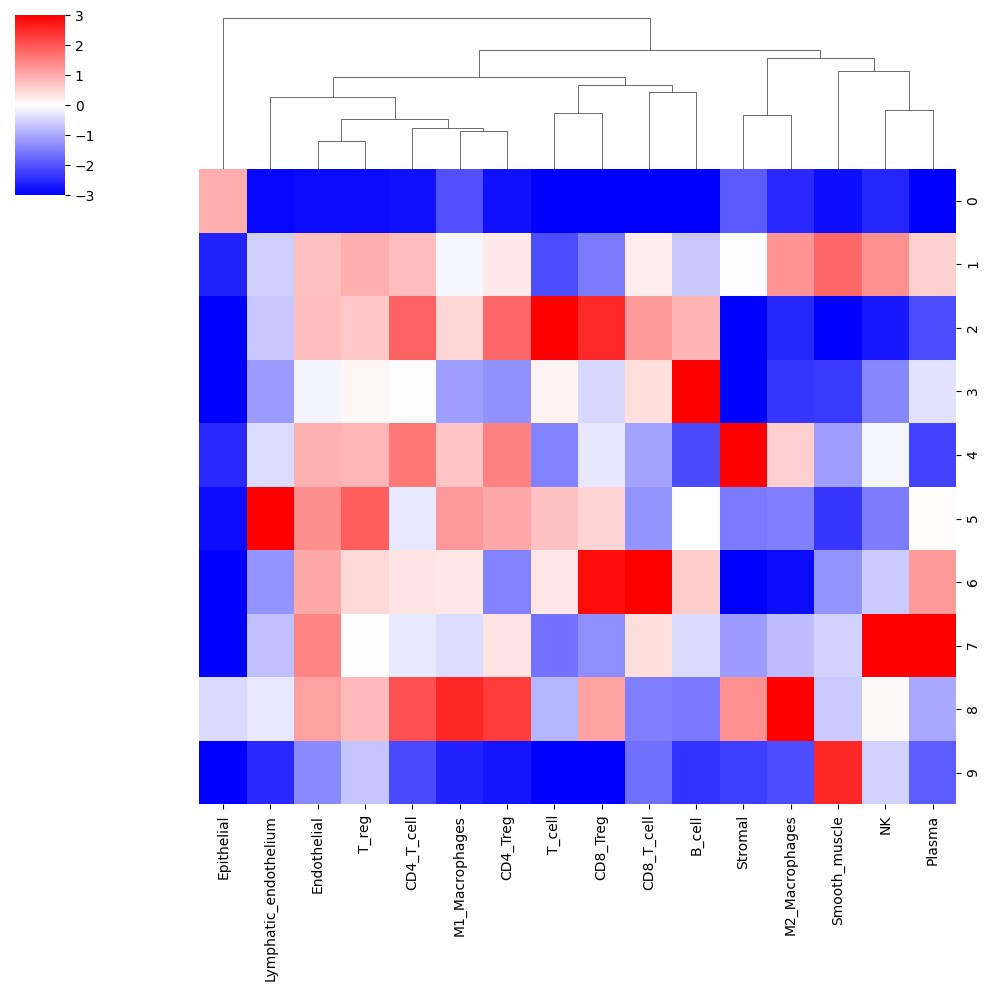

In [45]:
# this plot shows the types of cells (ClusterIDs) in the different niches (0-7)
k_to_plot = 10
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
s=sns.clustermap(fc.loc[[0,1,2,3,4,5,6,7,8,9]], vmin =-3,vmax = 3,cmap = 'bwr',row_cluster = False)
# s.savefig("raw_figs/celltypes_perniche_10.pdf")


In [46]:
neighborhoods = sorted(cells['neighborhood10'].unique())
palette = sns.color_palette("tab10", len(neighborhoods))  # or use your own palette

# Build the color map
color_map = dict(zip(neighborhoods, palette))

## Distribution of the different ncihes across the ROIs.

In [ ]:
cells['neighborhood10'] = cells['neighborhood10'].astype('category')


samples = cells['sample_region'].unique()
n_cols = 3
n_rows = math.ceil(len(samples) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
axes = axes.flatten()

for i, sample in enumerate(samples):
    sample_data = cells[cells['sample_region'] == sample]
    ax = axes[i]

    sns.scatterplot(
        data=sample_data,
        x='xmean', y='ymean',
        hue='neighborhood10',
        s=10,
        linewidth=0,
        ax=ax
    )

    ax.set_title(f"Neighborhood Spatial Layout - {sample}")
    ax.set_aspect('equal')
    ax.axis('off')
    ax.legend(title="Neighborhood", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize=9)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


###### -------------------------------

## Proportion of the new clusters (niches) across each ROI.

In [ ]:
df = pd.crosstab(cells['sample_region'], cells['neighborhood10'], normalize='index')
df = df.loc[[s for s in desired_order if s in df.index]]

# Ensure correct column order
df = df[neighborhoods]

# Apply colors from your color_map
colors = [color_map[n] for n in df.columns]

# Plot
ax = df.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)

# Formatting
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Neighborhood')
ax.grid(False)
plt.title('Percentage of Cellular Neighbors')
plt.xlabel('Sample Name')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()

## Proportion samples colored by condition in each neighbor.

In [ ]:
df = pd.crosstab(cells['neighborhood10'],cells['sample_region'],  normalize='index')

conditions = df.columns.to_series().apply(
    lambda x: re.search(r'(tumor(?:_\w+)?)$', str(x))  # capture "_tumor" or "_tumor_xxx"
).apply(lambda m: m.group(1) if m else "other")
unique_conds = conditions.unique()

sorted_cols = [col for cond in unique_conds for col in df.columns if conditions[col] == cond]

palette = plt.cm.tab10.colors  # or tab20 for more variety
color_map = {cond: palette[i % len(palette)] for i, cond in enumerate(unique_conds)}
df=df[sorted_cols]
bar_colors = [color_map[conditions[col]] for col in sorted_cols] 

# Plot
ax = df.plot(kind='bar', stacked=False, figsize=(10, 6), color=bar_colors, width=0.9)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Condition')


# Formatting
ax.grid(False)
plt.title('Percentage of Cellular Neighbors')
plt.xlabel('Neighbors')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()

## Create json file for Qupath

In [50]:


import json
import pandas as pd
import random

def generate_color_map_from_df(df, classification_col):
    """
    Generate QuPath-compatible color map (integer RGB values) for each unique cell type.
    Uses Java AWT format: R + G*256 + B*65536 as signed int.
    """
    def rgb_to_awt_int(r, g, b):
        """Convert RGB 0–255 to signed 32-bit int like QuPath uses."""
        value = (r << 16) + (g << 8) + b
        if value > 0x7FFFFFFF:  # convert to signed
            value -= 0x100000000
        return value

    unique_classes = sorted(df[classification_col].dropna().unique())
    color_map = {}
    for cls in unique_classes:
        r, g, b = [random.randint(0, 255) for _ in range(3)]
        color_map[cls] = rgb_to_awt_int(r, g, b)
    return color_map

import math

def circle_coordinates(cx, cy, radius=10, num_points=30):
    """
    Generate coordinates approximating a circle polygon.
    - radius=10 for a bigger circle (adjust as needed)
    - num_points=30 for smoothness
    """
    return [
        [cx + radius * math.cos(2 * math.pi * i / num_points),
         cy + radius * math.sin(2 * math.pi * i / num_points)]
        for i in range(num_points + 1)  # +1 closes the polygon
    ]

    
def create_qupath_geojson_from_table(df, output_path="QuPath_NoMasks.geojson",
                                     classification_col='celltype', max_objects=500):
    """
    Create QuPath-compatible GeoJSON from a plain table of cell info.
    No masks required — uses centroids to make tiny polygons.
    
    Expected columns in df:
    - cell_id
    - xmean
    - ymean
    - celltype (or your chosen classification_col)
    - area (optional)
    """

    print("🔧 Creating QuPath-compatible GeoJSON from table (no masks)")
    print("=" * 50)
    
    geojson = {
        "type": "FeatureCollection",
        "features": []
    }

    # Sort by area if available, then limit
    area_col = None
    for possible_col in ['area', 'Cell Area (µm²)', 'Area']:
        if possible_col in df.columns:
            area_col = possible_col
            df = df.sort_values(possible_col, ascending=False)
            break

    df = df.head(max_objects)
    print(f"Processing {len(df)} cells...")

    # Generate a color map for all unique cell types
    color_map = generate_color_map_from_df(df, classification_col)

    print("🎨 Generated color map:")
    for k, v in color_map.items():
        print(f"   {k}: {v}")

    for idx, row in df.iterrows():
        try:
            cell_id = int(row.get('cell_id', idx + 1))
            cx = float(row['xmean'])
            cy = float(row['ymean'])
            cell_classification = str(row.get(classification_col, 'Unknown'))
            color = color_map.get(cell_classification, -1)

            # Create tiny square polygon so QuPath accepts it
            size = 1
            coordinates = circle_coordinates(cx, cy, radius=10, num_points=30)

            # Build measurements, ensuring only numeric values are converted
            measurements = {
                "Cell_ID": cell_id
            }
            if area_col:
                try:
                    measurements["Cell Area (µm²)"] = float(row[area_col])
                except (ValueError, TypeError):
                    measurements["Cell Area (µm²)"] = 0.0

            # Add other numeric columns automatically
            for col in df.columns:
                if col not in ['cell_id', 'xmean', 'ymean', classification_col, area_col]:
                    try:
                        measurements[col] = float(row[col])
                    except (ValueError, TypeError):
                        continue  # skip non-numeric

            feature = {
                "type": "Feature",
                "geometry": {
                    "type": "Polygon",
                    "coordinates": [coordinates]
                },
                "properties": {
                    "classification": {
                        "name": cell_classification,
                        "colorRGB": color
                    },
                    "isLocked": False,
                    "measurements": measurements,
                    "objectType": "detection"
                }
            }

            feature["properties"]["objectType"] = "detection"
            geojson["features"].append(feature)

        except Exception as e:
            print(f"⚠️ Error with cell {cell_id}: {e}")
            continue

    
    # Save GeoJSON and print info + export .qlf for QuPath classes
    try:
        with open(output_path, 'w') as f:
            json.dump(geojson, f, indent=2)
        
        print(f"\n🎉 FIXED GEOJSON EXPORTED!")
        print(f"📁 File: {output_path}")
        print(f"📊 Objects: {len(geojson['features'])}")
        
        # Show what's included
        classifications = {}
        for feature in geojson["features"]:
            class_name = feature["properties"]["classification"]["name"]
            classifications[class_name] = classifications.get(class_name, 0) + 1
        
        print(f"\n📋 EXPORTED CELL TYPES:")
        for class_name, count in sorted(classifications.items(), key=lambda x: x[1], reverse=True):
            color_rgb = color_map.get(class_name, -1)
            print(f"   {class_name}: {count} cells (Color: {color_rgb})")
        
        print(f"\n✅ QUPATH IMPORT FIXES:")
        print("- All measurements are NUMERIC")
        print("- Removed confidence score requirement")
        print("- Proper polygon coordinate format")
        print("- Added objectType property")
        print("- Color-coded classifications for your cell types")

        # Export .qlf file
        qlf_file = export_qupath_class_hierarchy(color_map, output_path="cell_types.qlf")
        if qlf_file:
            print(f"\n🎯 QuPath class hierarchy exported:")
            print(f"   {qlf_file}")
            print("\n📥 TO IMPORT:")
            print("1. QuPath → Annotations → Manage Classes → Import Classes")
            print(f"2. Select: {qlf_file}")
            print("3. Then import the GeoJSON objects")

        print(f"\n📥 TO IMPORT GEOJSON:")
        print("1. QuPath → Objects → Import objects → From file")
        print(f"2. Select: {output_path}")
        print("3. Should import without errors now!")
        
        return output_path
        
    except Exception as e:
        print(f"❌ Error saving: {e}")
        return None

In [ ]:
for sample in clean_all_sample_merged_table['sample_region'].unique():
    subset_df = clean_all_sample_merged_table[clean_all_sample_merged_table['sample_region'] == sample]
    
    output_name = f"{sample}.geojson"
    
    create_qupath_geojson_from_table(
        subset_df,
        classification_col='celll_type',
        output_path=output_name,
        max_objects=50000
    )
    
    print(f"Saved {output_name} with {len(subset_df)} objects")